**Notes On Readings**

The original study by Aungle & Langer (2023) is structured in which participants got standardized cupping induced bruises and were told 3 different “false” amounts of time had elapsed during healing observations: in half time, normal time, or double time. Blind raters judged the bruises to have healed significantly more in the condition where participants believed more time had passed. The authors framed this as evidence for the concept of “mind-body unity,” where subjective time perception affects recovery, irrespective of actual elapsed time.

Gelman & Brown are skeptical because the model let each person have their own starting point for healing but forced everyone to have the same treatment effect. Each individuals healing ability varies to some degree. The model assumed that the healing ability given time manipulation was a fixed number change, applied identically to everyone. Another issue they raised is the literatures used to support their argument were unreplicated, methdologically shaky, or simply mischaracterized.


In [51]:
## Uncomment next comment to install packages
## %pip install numpy matplotlib pandas 
## %pip install pandas

## Import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Part 1: Garden of Forking Paths

Given the question, suppose there are $N$ different reasonable ways to analyze a dataset. The hypothesis $H$ is actually true, but each analysis has probability $q$ (Type I error rate) of incorrectly rejecting $H$.

### Part (a)

Assuming the $N$ outcomes are independent, what is the probability that at least one analysis incorrectly rejects $H$?

Either at least one analysis rejects or none do, so $P(\text{at least one rejects}) = 1 - P(\text{none reject})$

Each analysis fails to reject with probability $1 - q$, and since the outcomes are independent, the probabilities multiply ($P(x,y) = P(x)P(y)$):

$$P(\text{none reject}) = (1-q)^N$$

Therefore:

$$\boxed{P(\text{at least one rejects}) = 1 - (1-q)^N}$$

### Part (b)

With $q = 0.05$, find $N$ such that $P(\text{at least one rejects}) \geq 0.5$:

$$1 - (0.95)^N = 0.5 \implies (0.95)^N = 0.5 \implies N = \frac{\log 0.5}{\log 0.95} \approx 13.51$$

So $N = 14$ analyses are enough to give a 50% chance of at least one false rejection.

The plot below shows the formula from part (a); the curve crosses the 50% line between $N = 13$ and $N = 14$.

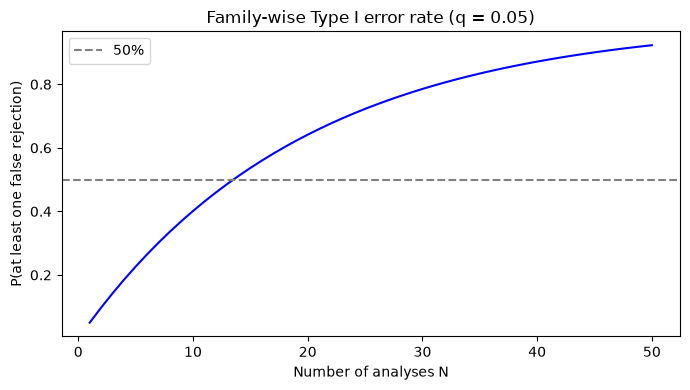

In [52]:
q = 0.05
N_vals = np.arange(1, 51)
prob = 1 - (1 - q) ** N_vals # closed form from part (a) for N = 1..50

plt.figure(figsize=(7, 4))
plt.plot(N_vals, prob, color="blue")
plt.axhline(0.5, color="gray", linestyle="--", label="50%") # where the curve crosses = answer to (b)
plt.xlabel("Number of analyses N")
plt.ylabel("P(at least one false rejection)")
plt.title(f"Family-wise Type I error rate (q = {q})")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
q = 0.05
rng = np.random.default_rng(42) # seeded so the results are reproducible
trials = 100_000

# smallest N where the part (a) formula reaches 50%
N = 1
while 1 - (1 - q) ** N < 0.5:
    N += 1
print(f"Smallest N with P(at least one rejects) >= 0.5: {N}")

for N_check in [N - 1, N]: # 14 should be the first N to reach 50%
    analytical = 1 - (1 - q) ** N_check
    # M = number of false rejections among N independent analyses ~ Binomial(N, q)
    M = rng.binomial(n=N_check, p=q, size=trials)
    sim_prob = np.mean(M >= 1) # fraction of trials with at least one rejection
    print(f"N={N_check}: analytical {analytical:.4f}, simulated {sim_prob:.4f}")

Smallest N with P(at least one rejects) >= 0.5: 14
N=13: analytical 0.4867, simulated 0.4883
N=14: analytical 0.5123, simulated 0.5098


### Part (c)

Analyses of the same dataset share the same data, so they are usually positively correlated. Let $p$ be the correlation between any two analyses.

If $p = 0$ the analyses are independent and the answer from (a), $1-(1-q)^N$, holds. If $p = 1$ every analysis gives the same result, so the probability drops to $q$. For $p$ in between it should land between $q$ and $1-(1-q)^N$. Correlation shrinks the problem but doesn't remove it. Negative correlation could push the probability above the independent case, but that is unlikely for analyses of one dataset, so I only simulate $p \geq 0$.

For the simulation, let $X_i = 1$ if analysis $i$ falsely rejects, so $X_i \sim \text{Bernoulli}(q)$. In each trial, with probability $p$ all $N$ analyses copy one shared outcome (reject with probability $q$). Otherwise each gets its own independent outcome. Every $X_i$ is still $\text{Bernoulli}(q)$.

Check that $p$ is the correlation. If two analyses agree, both reject with probability $q$. If not, both reject with probability $q^2$. So $E[X_iX_j] = pq + (1-p)q^2$, and

$$\text{cov}(X_i,X_j) = E[X_iX_j] - E[X_i]E[X_j] = pq + (1-p)q^2 - q^2 = p\,q(1-q).$$

Since $\text{var}(X_i) = q(1-q)$, dividing gives $\text{corr}(X_i,X_j) = p$.

Conditioning on whether the analyses agree gives the probability the simulation should match:

$$P(\text{at least one rejects}) = pq + (1-p)\bigl(1-(1-q)^N\bigr).$$

This equals $1-(1-q)^N$ at $p=0$ and $q$ at $p=1$.

In [54]:
rng = np.random.default_rng(42)
q = 0.05
N = 14
trials = 100_000
probs_reject = [1 - q, q] # P(no reject), P(reject) for one analysis

print(f"{'p':>5}  {'simulated':>10}  {'formula':>8}  {'sample corr':>12}")
print("-" * 41)
for p in [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]: # p = correlation = prob. the analyses agree
    # 1 = analyses agree this trial (prob p), 0 = independent
    agree = rng.choice([0, 1], p=[1 - p, p], size=trials)
    shared = rng.choice([0, 1], p=probs_reject, size=(trials, 1)) # one outcome copied to all N
    X = rng.choice([0, 1], p=probs_reject, size=(trials, N)) # each analysis's own outcome
    X[agree == 1] = shared[agree == 1] # agreeing trials use the shared outcome

    sim = np.mean(np.sum(X, axis=1) >= 1) # at least one of N rejects
    formula = p * q + (1 - p) * (1 - (1 - q) ** N) # conditioning on agree / not agree
    C = np.cov(X[:, 0], X[:, 1]) # analyses 1 and 2 (any pair works)
    corr = C[0, 1] / C[0, 0] # cov/var; equal variances, so this is p
    print(f"{p:>5.1f}  {sim:>10.4f}  {formula:>8.4f}  {corr:>12.3f}")

    p   simulated   formula   sample corr
-----------------------------------------
  0.0      0.5124    0.5123         0.004
  0.3      0.3732    0.3736         0.299
  0.5      0.2854    0.2812         0.507
  0.7      0.1886    0.1887         0.706
  0.9      0.0954    0.0962         0.890
  1.0      0.0492    0.0500         1.000


## Part 2: Exploring the real healing data

In [55]:
## Loading data with code given

url = (
"https://media.springernature.com/original/springer-static/esm/"
"art%3A10.1038%2Fs41598-023-50009-3/MediaObjects/"
"41598_2023_50009_MOESM4_ESM.csv"
)
df = pd.read_csv(url)
df["S"] = pd.factorize(df["Subject"])[0] + 1 # subject id, 1-33
df["R"] = pd.factorize(df["ResponseId"])[0] + 1 # rater id, 1-25
X = df[["Condition", "Session", "Healing", "Age", "Gender", "S", "R"]].to_numpy()
X

array([[14, 2, 7.5, ..., 'Male', 1, 1],
       [14, 2, 0.0, ..., 'Male', 1, 2],
       [14, 2, 8.7, ..., 'Male', 1, 3],
       ...,
       [56, 3, 5.3, ..., 'Female', 33, 20],
       [28, 2, 5.7, ..., 'Female', 33, 20],
       [56, 3, 9.0, ..., 'Female', 33, 4]], shape=(2425, 7), dtype=object)

In [56]:
df.head() # this is stuff I learned from qss20

,Subject,ResponseId,Condition,Session,Healing,Session_Mood,Age,Gender,Race,PSS_sum,Mindfulness,Extraversion,Agreeableness,Conscientiousness,Neuroticism,Openness,Dscale,Ascale,S,R
0,111191,R_pgXW2ib04rk04U1,14,2,7.5,6.238,22,Male,White,19,85,6.0,3.0,5.0,3.5,4.0,1,6,1,1
1,111191,R_1DZrj0mXFNlzerG,14,2,0.0,6.238,22,Male,White,19,85,6.0,3.0,5.0,3.5,4.0,1,6,1,2
2,111191,R_2e2Lr3jZB2CVAh6,14,2,8.7,6.238,22,Male,White,19,85,6.0,3.0,5.0,3.5,4.0,1,6,1,3
3,111191,R_1QtmXo279oXTu6f,14,2,2.9,6.238,22,Male,White,19,85,6.0,3.0,5.0,3.5,4.0,1,6,1,4
4,111191,R_2Tt4FbnxiErpj5o,28,3,2.0,6.238,22,Male,White,19,85,6.0,3.0,5.0,3.5,4.0,1,6,1,5


In [57]:
# what values does each column of X take?
names = ["Condition", "Session", "Healing", "Age", "Gender", "S", "R"]
for j, name in enumerate(names):
    values = sorted(set(X[:, j])) # unique values in column j
    if len(values) <= 5:
        counts = [int(np.sum(X[:, j] == v)) for v in values] # rows with each value
        print(f"{name}: {len(values)} unique -> {dict(zip(values, counts))}")
    else:
        print(f"{name}: {len(values)} unique, from {values[0]} to {values[-1]}")

Condition: 3 unique -> {14: 800, 28: 825, 56: 800}
Session: 3 unique -> {1: 825, 2: 825, 3: 775}
Healing: 101 unique, from 0.0 to 10.0
Age: 20 unique, from 19 to 45
Gender: 2 unique -> {'Female': 1725, 'Male': 700}
S: 33 unique, from 1 to 33
R: 25 unique, from 1 to 25


In [58]:
condition = X[:, 0].astype(int)
session = X[:, 1].astype(int)
healing = X[:, 2].astype(float)
subject = X[:, 5].astype(int)
rater = X[:, 6].astype(int)
conds = [14, 28, 56]

In [59]:
# how many different sessions did each rater see?
sessions_per_rater = [len(set(session[rater == r])) for r in range(1, 26)]
print("sessions seen per rater: min", min(sessions_per_rater), "max", max(sessions_per_rater))

# how many different raters rated each participant?
raters_per_subject = [len(set(rater[subject == s])) for s in range(1, 34)]
print("distinct raters per participant: min", min(raters_per_subject), "max", max(raters_per_subject))

# ratings each rater gave in each condition (25 raters x 3 conditions)
counts = np.array([[np.sum((rater == r) & (condition == c)) for c in conds] for r in range(1, 26)])
print("ratings per rater in each condition: min", counts.min(), "max", counts.max())

# how condition lines up with session (rows: condition, columns: session 1/2/3)
print("\nrows: condition (down) x session (across)")
for c in conds:
    print(c, [int(np.sum((condition == c) & (session == s))) for s in [1, 2, 3]])

sessions seen per rater: min 3 max 3
distinct raters per participant: min 25 max 25
ratings per rater in each condition: min 32 max 33

rows: condition (down) x session (across)
14 [350, 200, 250]
28 [150, 550, 125]
56 [325, 75, 400]


Raters were not assigned to sessions. Every rater saw all three sessions, and all 25 raters rated every participant. Each rater also gave 32 or 33 ratings per condition, so no rater favored one condition.

That makes the design fully crossed, so a harsh rater pulls down every condition equally. The downside is that raters saw all of a person's photos, so they could compare a person's sessions against each other even without knowing the condition.

Condition and session are also tangled up. Condition 28 is mostly session 2, condition 14 is mostly session 1, and condition 56 is mostly sessions 1 and 3. If bruises faded or raters got used to the scale over time, that could look like a condition effect. Also, the 25 ratings of one photo are not independent, so we really have about 33 people, not 2425 ratings.

In [60]:
for c in conds:
    print(f"condition {c}: mean healing {np.mean(healing[condition == c]):.3f}")

print("\nmean (n) by session 1 / 2 / 3")
for c in conds:
    row = []
    for s in [1, 2, 3]:
        m = (condition == c) & (session == s)          # rows in this condition and session
        row.append(f"{np.mean(healing[m]):.2f} (n={np.sum(m)})")
    print(c, row)

condition 14: mean healing 6.172
condition 28: mean healing 6.430
condition 56: mean healing 7.297

mean (n) by session 1 / 2 / 3
14 ['6.43 (n=350)', '5.74 (n=200)', '6.15 (n=250)']
28 ['6.48 (n=150)', '6.49 (n=550)', '6.10 (n=125)']
56 ['6.94 (n=325)', '7.71 (n=75)', '7.51 (n=400)']


Average healing goes up with the perceived time: 6.17, 6.43, and 7.30 for 14, 28, and 56. Condition 56 is the highest in every session, but its session 2 cell has only 75 ratings, so that 7.71 is noisy. Conditions 14 and 28 are close and swap places in session 3.

In [61]:
# variance across participants within each condition
# (each participant's mean rating in that condition, averaged over the 25 raters)
within = []
for c in conds:
    pmeans = [np.mean(healing[(condition == c) & (subject == s)])
              for s in range(1, 34) if np.sum((condition == c) & (subject == s)) > 0]
    within.append(np.var(pmeans))
    
cond_means = [np.mean(healing[condition == c]) for c in conds]
print("variance across participants within condition:", np.round(within, 3), "average", round(np.mean(within), 3))
print("variance across the three condition means:", round(np.var(cond_means), 3))

# same idea at the rating level: var(Y) splits into E[var(Y|cond)] + var(E[Y|cond])  (Unit 2)
weights = [np.mean(condition == c) for c in conds]
between = np.sum([w * (m - np.mean(healing)) ** 2 for w, m in zip(weights, cond_means)])
print("var(E[Y|cond]) =", round(between, 3), " var(Y) =", round(np.var(healing), 3),
      " share explained =", round(between / np.var(healing), 3))

variance across participants within condition: [2.99  2.144 2.133] average 2.422
variance across the three condition means: 0.231
var(E[Y|cond]) = 0.229  var(Y) = 6.308  share explained = 0.036


Within a condition, the variance across participants is about 2.4 (2.99, 2.14, 2.13). The variance of the three condition means is 0.23. So people differ from each other about ten times as much as the conditions differ. The rating-level version says the same thing: using the variance split from Unit 2, condition accounts for only about 4% of var(Y) (0.229 out of 6.308).

The 1.1 point gap between 14 and 56 is small next to how much people vary, so the means alone can't tell us whether the gap is more than noise. That is what the randomization test in Part (iii) is for.